In [1]:
import copy
from IPython.display import display, Image
import logging
import numpy
import os
import pandas
import pdb
import plotly
import pprint
import pyarrow
import pyarrow.parquet as pq
import six
import sys
import tensorflow as tf
import time

import CS230

plotly.offline.init_notebook_mode(connected=True)

In [2]:
logger = CS230.common.get_logger(level=logging.INFO)

In [3]:
file_paths = CS230.data.get_all_file_paths()
logger.debug(file_paths)
logger.info('num files: %s', len(file_paths))

11-35-55 | INFO | num files: 22


In [8]:
image_paths = []

for file_path in file_paths:
    image_dir = os.path.join('images', file_path.split('/')[-2])
    
    df = CS230.data.load(file_path)
    df = CS230.data.stride_rows(df, stride=10)
    df = CS230.data.add_derivs(df, stride=1)
    df = CS230.data.clean_discontinuities(df, stride=1)
    
    # mkdir if necessary
    dir_name = os.path.join('images', file_path.split('/')[-2])
    if not os.path.exists(dir_name):
        os.mkdir(dir_name)
    
    # plot source
    start = CS230.data.DEFAULT_START
    stop = CS230.data.DEFAULT_STOP
    step = CS230.data.DEFAULT_STEP
    image_path = os.path.join(image_dir, os.path.splitext(file_path.split('/')[-1])[0] + '.jpeg')
    title = '{image_path}<br><b>source data zoomed-out</b>: sampled with 1D stride={step}'.format(image_path=image_path, step=step)
    columns=CS230.data.COLUMNS_ORIG
    fig = CS230.data.write_image(df=df, title=title, image_path=image_path, columns=columns, 
                                 start=start, stop=stop, step=step)
    image_paths.append(image_path)
    #plotly.offline.iplot(fig)
    
    # plot source zoomed
    start = len(df) // 2
    stop = start + 200
    step = 1
    image_path = os.path.join(image_dir, os.path.splitext(file_path.split('/')[-1])[0] + '_zoom.jpeg')
    title = '{image_path}<br><b>source data zoomed-in</b>: indexes {start} : {stop}'.format(image_path=image_path, start=start, stop=stop)
    columns = CS230.data.COLUMNS_ORIG
    fig = CS230.data.write_image(df=df, title=title, image_path=image_path, columns=columns, 
                                 start=start, stop=stop, step=step)
    image_paths.append(image_path)
    #plotly.offline.iplot(fig)
    
    # plot derivatives
    start = CS230.data.DEFAULT_START
    stop = CS230.data.DEFAULT_STOP
    step = CS230.data.DEFAULT_STEP
    image_path = os.path.join(image_dir, os.path.splitext(file_path.split('/')[-1])[0] + '_deriv.jpeg')
    title = '{image_path}<br><b>derivatives zoomed-out</b>: sampled with 1D stride={step}'.format(image_path=image_path, step=step)
    columns=CS230.data.DERIV_COLUMNS
    fig = CS230.data.write_image(df=df, title=title, image_path=image_path, columns=columns, 
                                 start=start, stop=stop, step=step)
    image_paths.append(image_path)
    #plotly.offline.iplot(fig)
    
    # plot derivatives zoomed
    start = len(df) // 2
    stop = start + 200
    step = 1
    image_path = os.path.join(image_dir, os.path.splitext(file_path.split('/')[-1])[0] + '_deriv_zoom.jpeg')
    title = '{image_path}<br><b>derivatives zoomed-in</b>: indexes {start} : {stop}'.format(image_path=image_path, start=start, stop=stop)
    columns=CS230.data.DERIV_COLUMNS
    fig = CS230.data.write_image(df=df, title=title, image_path=image_path, columns=columns, 
                                 start=start, stop=stop, step=step)
    image_paths.append(image_path)
    #plotly.offline.iplot(fig)
    
    del df  # delete DataFrame to avoid running out of memory

logger.info('num images saved: %s', len(image_paths))

11-39-22 | INFO | wrote image file: images/2013_Monterey_Motorsports_Reunion/20130810_01_01_01_grandsport.jpeg
11-39-22 | INFO | wrote image file: images/2013_Monterey_Motorsports_Reunion/20130810_01_01_01_grandsport_zoom.jpeg
11-39-23 | INFO | wrote image file: images/2013_Monterey_Motorsports_Reunion/20130810_01_01_01_grandsport_deriv.jpeg
11-39-23 | INFO | wrote image file: images/2013_Monterey_Motorsports_Reunion/20130810_01_01_01_grandsport_deriv_zoom.jpeg
11-39-23 | INFO | wrote image file: images/2013_Monterey_Motorsports_Reunion/20130810_02_01_01_grandsport.jpeg
11-39-24 | INFO | wrote image file: images/2013_Monterey_Motorsports_Reunion/20130810_02_01_01_grandsport_zoom.jpeg
11-39-24 | INFO | wrote image file: images/2013_Monterey_Motorsports_Reunion/20130810_02_01_01_grandsport_deriv.jpeg
11-39-24 | INFO | wrote image file: images/2013_Monterey_Motorsports_Reunion/20130810_02_01_01_grandsport_deriv_zoom.jpeg
11-39-25 | INFO | wrote image file: images/2013_Monterey_Motorsports

11-39-42 | INFO | wrote image file: images/2014_Targa_Sixty-Six/20140221_04_01_03_250lm_zoom.jpeg
11-39-42 | INFO | wrote image file: images/2014_Targa_Sixty-Six/20140221_04_01_03_250lm_deriv.jpeg
11-39-42 | INFO | wrote image file: images/2014_Targa_Sixty-Six/20140221_04_01_03_250lm_deriv_zoom.jpeg
11-39-43 | INFO | wrote image file: images/2014_Targa_Sixty-Six/20140222_01_01_03_250lm.jpeg
11-39-43 | INFO | wrote image file: images/2014_Targa_Sixty-Six/20140222_01_01_03_250lm_zoom.jpeg
11-39-43 | INFO | wrote image file: images/2014_Targa_Sixty-Six/20140222_01_01_03_250lm_deriv.jpeg
11-39-43 | INFO | wrote image file: images/2014_Targa_Sixty-Six/20140222_01_01_03_250lm_deriv_zoom.jpeg
11-39-44 | INFO | wrote image file: images/2014_Targa_Sixty-Six/20140222_02_01_03_250lm.jpeg
11-39-44 | INFO | wrote image file: images/2014_Targa_Sixty-Six/20140222_02_01_03_250lm_zoom.jpeg
11-39-44 | INFO | wrote image file: images/2014_Targa_Sixty-Six/20140222_02_01_03_250lm_deriv.jpeg
11-39-44 | INFO

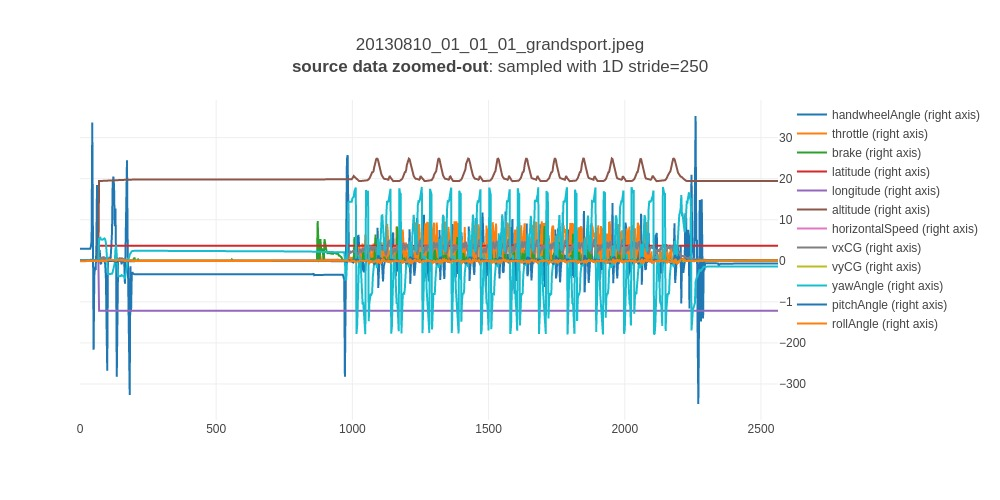

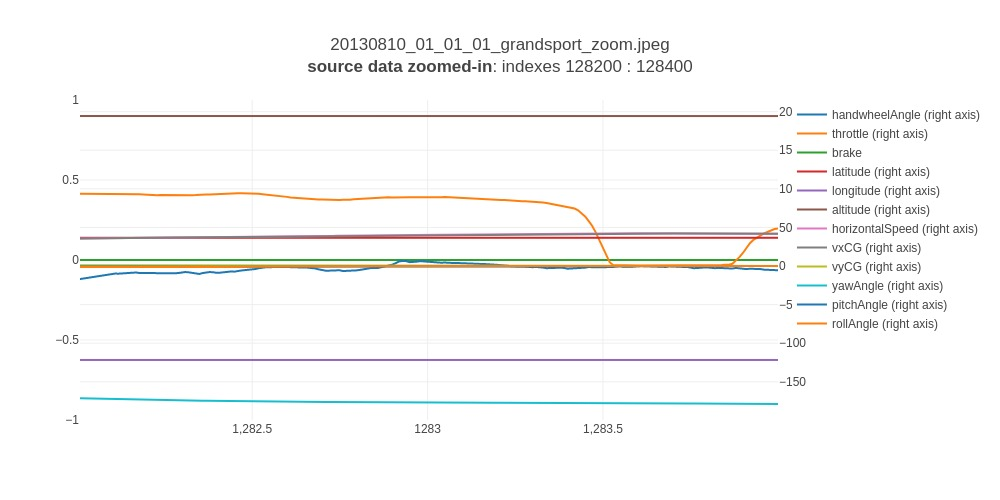

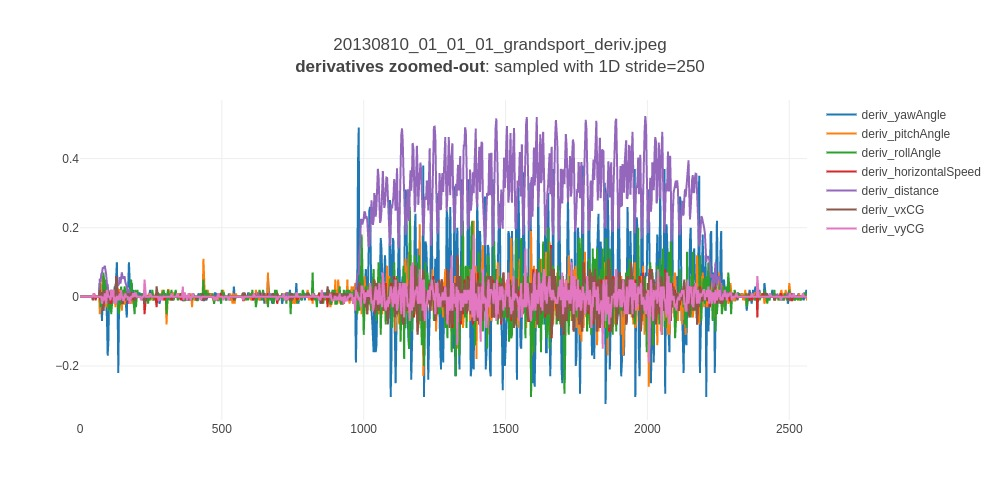

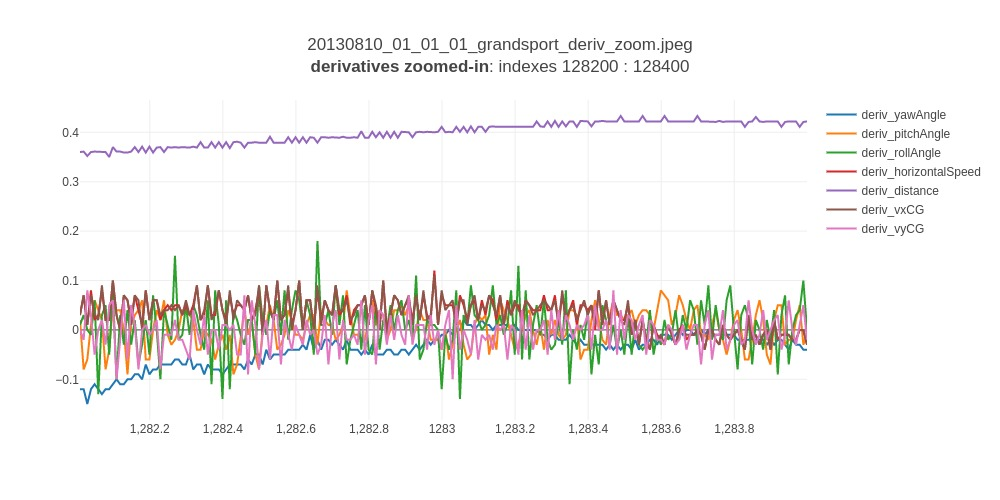

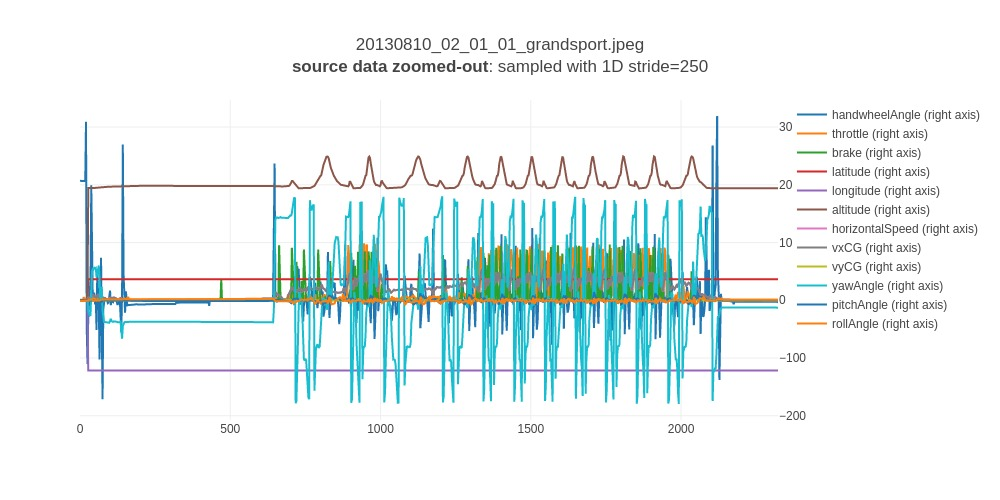

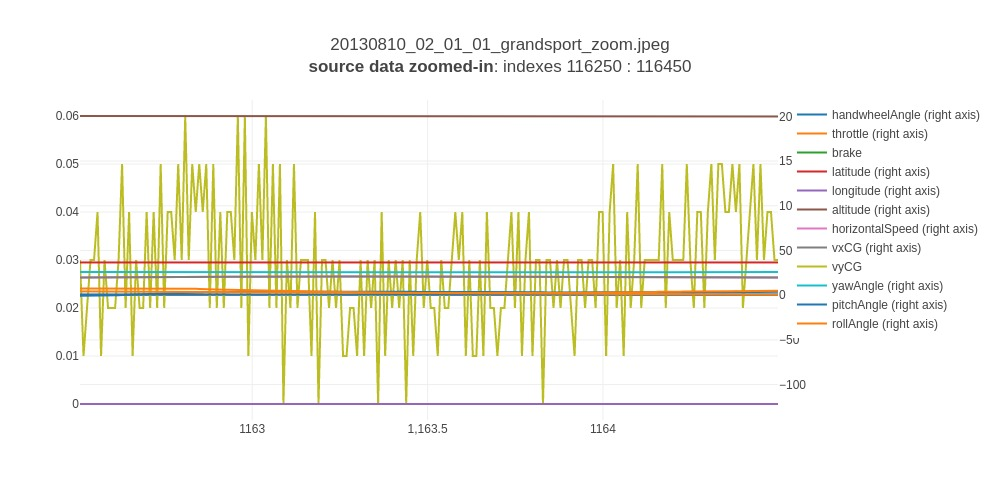

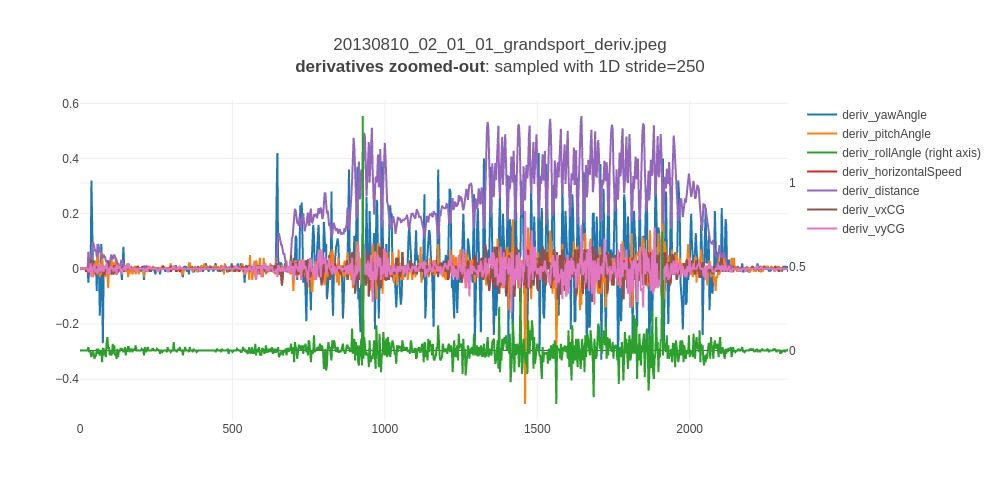

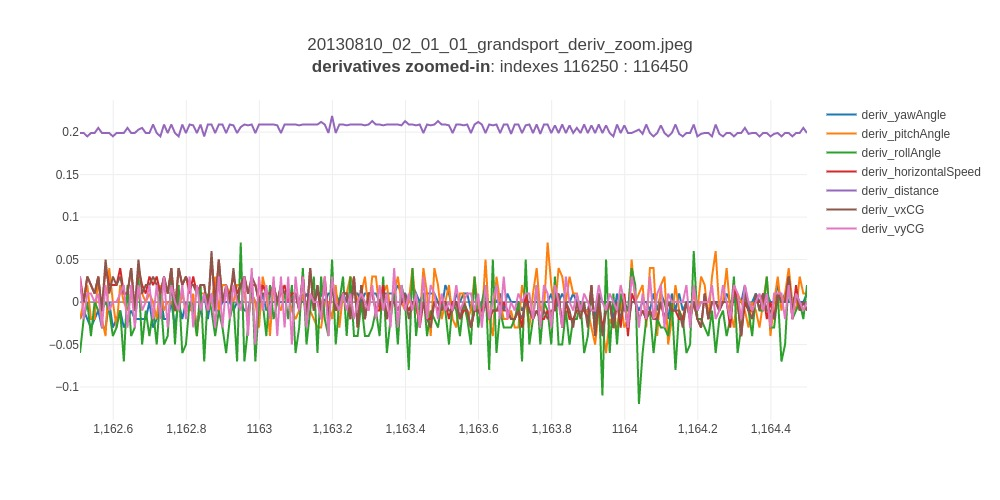

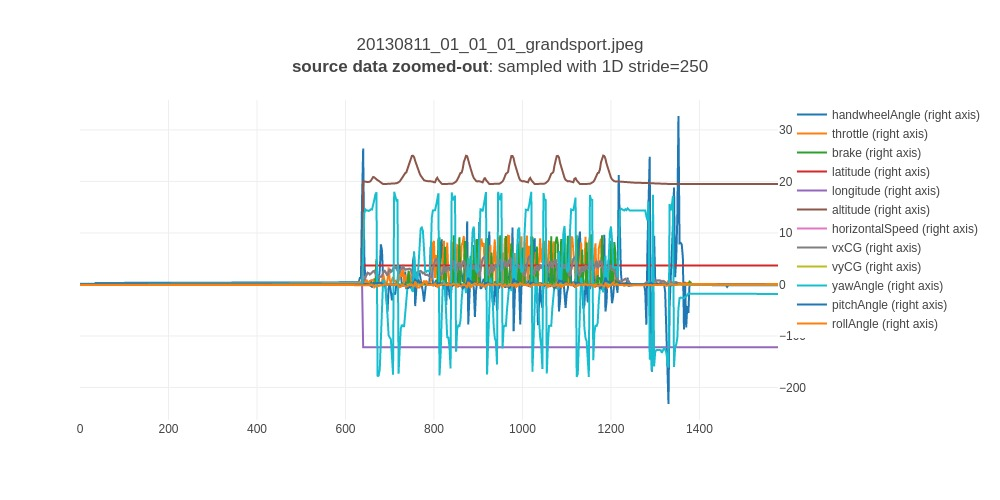

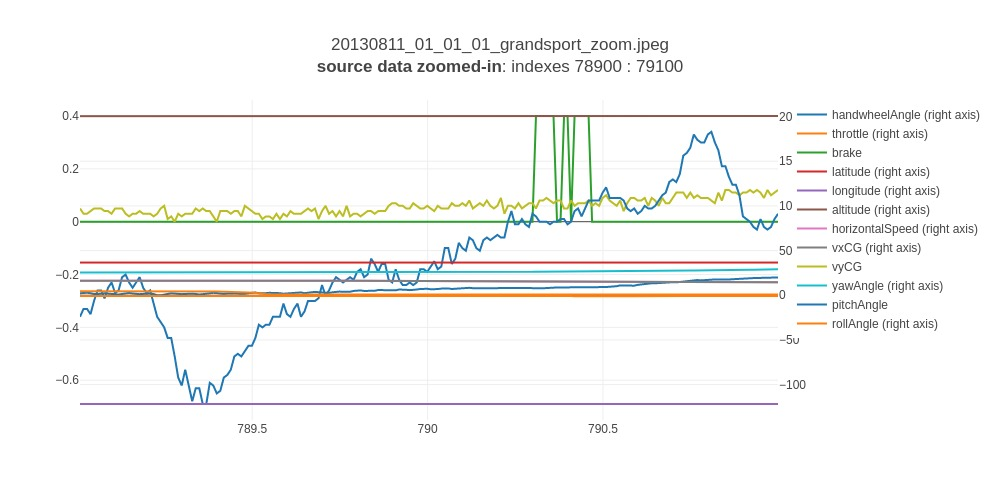

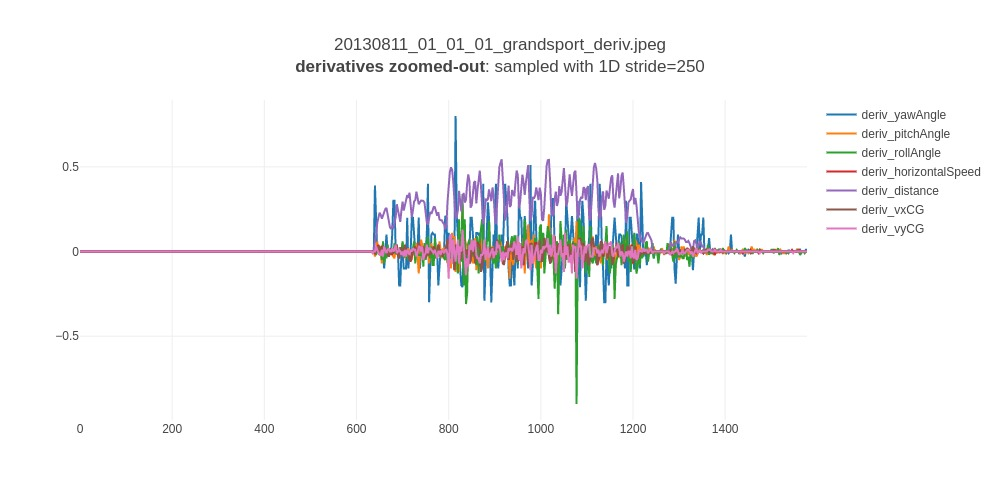

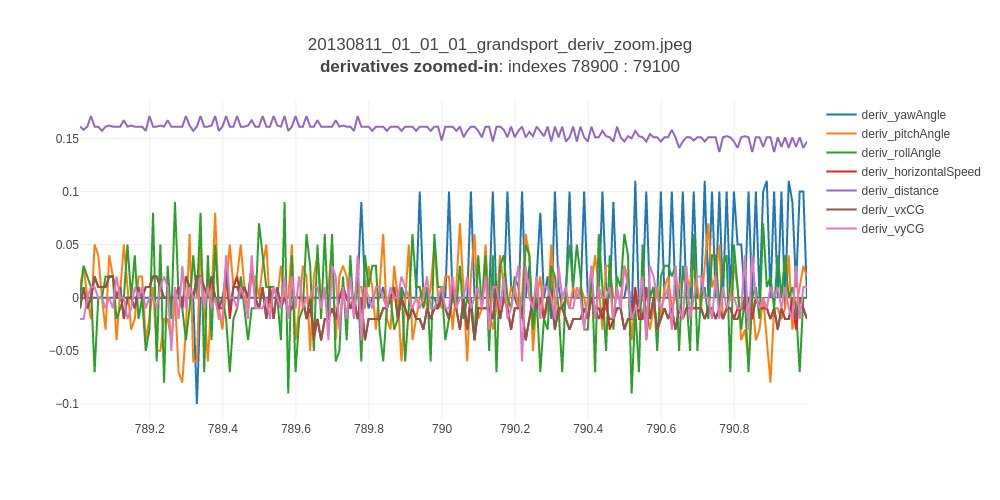

In [9]:
for i, image_path in enumerate(image_paths):
    display(Image(filename=image_path))
    
    if i > 10:
        break